In [2]:
import pandas as pd
import numpy as np

# Load the data from the Excel file
data = pd.read_excel('health-relatedindicators.xlsx')

# Display the first few rows
data.head()

,id,Country,year,sdg3_matmort,sdg3_neonat,sdg3_u5mort,sdg3_tb,sdg3_hiv,sdg3_ncds,sdg3_lifee,sdg3_fertility,sdg3_births,sdg3_vac
0,AFG,Afghanistan,2000,1346.0,62.693,131.639,190.0,0.03,41.66,55.298,NaN,NaN,27.0
1,AFG,Afghanistan,2001,1273.0,61.483,127.371,189.0,0.03,42.10,55.798,NaN,NaN,37.0
2,AFG,Afghanistan,2002,1277.0,60.209,123.022,189.0,0.04,42.06,56.454,177.6,NaN,35.0
3,AFG,Afghanistan,2003,1196.0,58.884,118.508,189.0,0.04,41.52,57.344,147.0,14.3,39.0
4,AFG,Afghanistan,2004,1115.0,57.473,114.038,189.0,0.04,41.36,57.944,NaN,NaN,48.0


In [15]:
# Select data in last 10 years
selected_columns = ['Country', 'year', 'sdg3_lifee', 'sdg3_vac']
filtered_data = data[(data['year'] >= 2015)][selected_columns]

# Check for missing values
print(filtered_data.isnull().sum())

Country         0
year            0
sdg3_lifee    579
sdg3_vac      394
dtype: int64


In [19]:
# Handle missing values
filtered_data = filtered_data.groupby('Country').apply(lambda group: group.fillna(method='ffill').fillna(method='bfill'))

# Check data after handling missing value
print(filtered_data.isnull().sum())

Country       0
year          0
sdg3_lifee    0
sdg3_vac      0
dtype: int64


/var/folders/fc/m91qtdls7mld56zp96k3mm0c0000gn/T/ipykernel_21458/1238753286.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  filtered_data = filtered_data.groupby('Country').apply(lambda group: group.fillna(method='ffill').fillna(method='bfill'))
/var/folders/fc/m91qtdls7mld56zp96k3mm0c0000gn/T/ipykernel_21458/1238753286.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  filtered_data = filtered_data.groupby('Country').apply(lambda group: group.fillna(method='ffill').fillna(method='bfill'))


In [27]:
# Pivot data for life expectancy (sdg3_lifee)
life_expectancy_pivot = filtered_data.pivot(index='Country', columns='year', values='sdg3_lifee')

# Pivot data for vaccine coverage (sdg3_vac)
vaccination_pivot = filtered_data.pivot(index='Country', columns='year', values='sdg3_vac')

# Check the data is in the correct format
print("Life Expectancy Data:")
print(life_expectancy_pivot.head())

print("\nVaccination Data:")
print(vaccination_pivot.head())

Life Expectancy Data:
year           2015    2016    2017    2018    2019    2020    2021    2022  \
Country                                                                       
Afghanistan  62.659  63.136  63.016  63.081  63.565  62.575  61.982  61.982   
Albania      78.644  78.860  79.047  79.184  79.282  76.989  76.463  76.463   
Algeria      75.622  75.732  75.743  76.066  76.474  74.453  76.377  76.377   
Andorra      82.953  82.967  82.980  82.992  83.004  79.023  80.368  80.368   
Angola       60.655  61.092  61.680  62.144  62.448  62.261  61.643  61.643   

year           2023    2024  
Country                      
Afghanistan  61.982  61.982  
Albania      76.463  76.463  
Algeria      76.377  76.377  
Andorra      80.368  80.368  
Angola       61.643  61.643  

Vaccination Data:
year         2015  2016  2017  2018  2019  2020  2021  2022  2023  2024
Country                                                                
Afghanistan  62.0  64.0  67.0  71.0  64.0  66.0  63

In [32]:

from sklearn.preprocessing import StandardScaler

# Normalize the life expectancy data
scaler = StandardScaler()
life_expectancy_scaled = scaler.fit_transform(life_expectancy_pivot)

# Convert the scaled data back into a DataFrame for easier interpretation
life_expectancy_scaled_df = pd.DataFrame(life_expectancy_scaled, index=life_expectancy_pivot.index, columns=life_expectancy_pivot.columns)

# Normalize the vaccination data
vaccination_scaled = scaler.fit_transform(vaccination_pivot)

# Convert the scaled data back into a DataFrame for easier interpretation
vaccination_scaled_df = pd.DataFrame(vaccination_scaled, index=vaccination_pivot.index, columns=vaccination_pivot.columns)
# Display normalized data to check
print("Normalized Life Expectancy Data:")
print(life_expectancy_scaled_df.head())

print("\nNormalized Vaccination Data:")
print(vaccination_scaled_df.head())


Normalized Life Expectancy Data:
year             2015      2016      2017      2018      2019      2020  \
Country                                                                   
Afghanistan -1.094489 -1.092537 -1.153963 -1.190740 -1.166089 -1.223487   
Albania      0.900095  0.903398  0.907792  0.908997  0.902370  0.702657   
Algeria      0.523015  0.506343  0.482863  0.502428  0.532819  0.363771   
Andorra      1.437766  1.424722  1.413617  1.405538  1.392209  0.974460   
Angola      -1.344545 -1.351993 -1.325786 -1.312919 -1.313094 -1.265447   

year             2021      2022      2023      2024  
Country                                              
Afghanistan -1.196499 -1.196499 -1.196499 -1.196499  
Albania      0.684905  0.684905  0.684905  0.684905  
Algeria      0.673732  0.673732  0.673732  0.673732  
Andorra      1.192252  1.192252  1.192252  1.192252  
Angola      -1.240543 -1.240543 -1.240543 -1.240543  

Normalized Vaccination Data:
year             2015      2016  

/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the valu

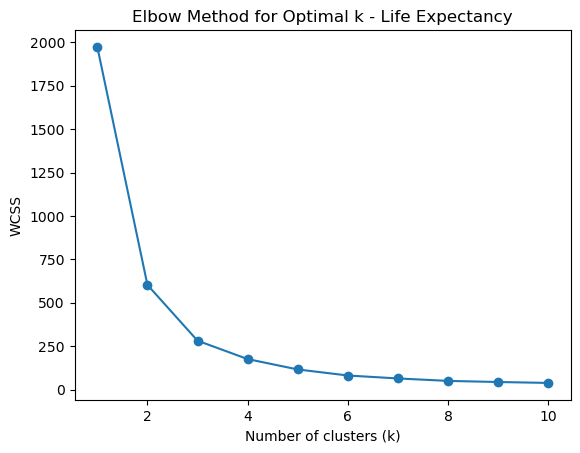

/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the valu

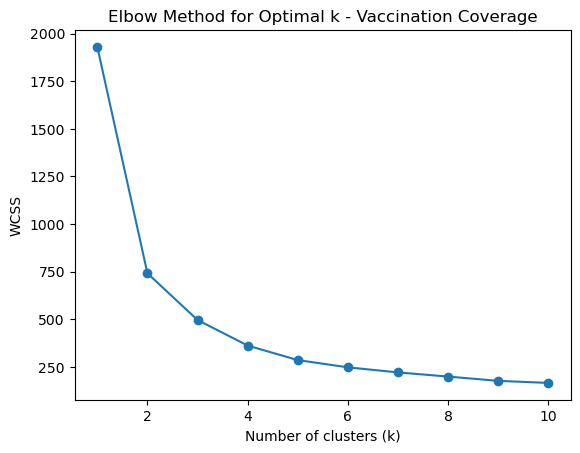

In [42]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Convert column names to strings for both DataFrames
life_expectancy_scaled_df.columns = life_expectancy_scaled_df.columns.astype(str)
vaccination_scaled_df.columns = vaccination_scaled_df.columns.astype(str)

# Define the function to plot the Elbow Method
def plot_elbow_method(data, title):
    wcss = []
    k_values = range(1, 11)  
    
    # Calculate WCSS for each k
    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42).fit(data)
        wcss.append(kmeans.inertia_)
    
    # Plot the WCSS values to determine the elbow point
    plt.plot(k_values, wcss, marker='o')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('WCSS')
    plt.title(f'Elbow Method for Optimal k - {title}')
    plt.show()

# Apply the Elbow Method individually to each indicator's DataFrame

# For Life Expectancy
plot_elbow_method(life_expectancy_scaled_df, title="Life Expectancy")

# For Vaccination Coverage
plot_elbow_method(vaccination_scaled_df, title="Vaccination Coverage")




In [52]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, fcluster

# Define the number of clusters
k = 3

### KMeans Clustering ###

# KMeans for Life Expectancy
kmeans_life = KMeans(n_clusters=k, random_state=42)
life_labels_kmeans = kmeans_life.fit_predict(life_expectancy_scaled_df.drop('Cluster', axis=1))
# Calculate Silhouette Score for KMeans on Life Expectancy
life_silhouette_kmeans = silhouette_score(life_expectancy_scaled_df.drop('Cluster', axis=1), life_labels_kmeans)
print(f"KMeans Silhouette Score for Life Expectancy (k=3): {life_silhouette_kmeans:.4f}")

# KMeans for Vaccination Coverage
kmeans_vac = KMeans(n_clusters=k, random_state=42)
vac_labels_kmeans = kmeans_vac.fit_predict(vaccination_scaled_df.drop('Cluster', axis=1))
# Calculate Silhouette Score for KMeans on Vaccination Coverage
vac_silhouette_kmeans = silhouette_score(vaccination_scaled_df.drop('Cluster', axis=1), vac_labels_kmeans)
print(f"KMeans Silhouette Score for Vaccination Coverage (k=3): {vac_silhouette_kmeans:.4f}")


### Hierarchical Clustering ###

# Hierarchical Clustering for Life Expectancy
linkage_life = linkage(life_expectancy_scaled_df.drop('Cluster', axis=1), method='ward')
life_labels_hierarchical = fcluster(linkage_life, t=k, criterion='maxclust')
# Calculate Silhouette Score for Hierarchical Clustering on Life Expectancy
life_silhouette_hierarchical = silhouette_score(life_expectancy_scaled_df.drop('Cluster', axis=1), life_labels_hierarchical)
print(f"Hierarchical Silhouette Score for Life Expectancy (k=3): {life_silhouette_hierarchical:.4f}")

# Hierarchical Clustering for Vaccination Coverage
linkage_vac = linkage(vaccination_scaled_df.drop('Cluster', axis=1), method='ward')
vac_labels_hierarchical = fcluster(linkage_vac, t=k, criterion='maxclust')
# Calculate Silhouette Score for Hierarchical Clustering on Vaccination Coverage
vac_silhouette_hierarchical = silhouette_score(vaccination_scaled_df.drop('Cluster', axis=1), vac_labels_hierarchical)
print(f"Hierarchical Silhouette Score for Vaccination Coverage (k=3): {vac_silhouette_hierarchical:.4f}")


KMeans Silhouette Score for Life Expectancy (k=3): 0.5631
KMeans Silhouette Score for Vaccination Coverage (k=3): 0.5245
Hierarchical Silhouette Score for Life Expectancy (k=3): 0.5516
Hierarchical Silhouette Score for Vaccination Coverage (k=3): 0.4622


/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [110]:
import pandas as pd

# Combine KMeans cluster labels into a single DataFrame
comparison_df = pd.DataFrame({
    'Country': life_expectancy_scaled_df.index,  
    'Life_Expectancy_Cluster': life_labels_kmeans,
    'Vaccination_Cluster': vac_labels_kmeans
})
comparison_df.head()



,Country,Life_Expectancy_Cluster,Vaccination_Cluster
0,Afghanistan,0,2
1,Albania,1,0
2,Algeria,2,2
3,Andorra,1,0
4,Angola,0,1


In [112]:
#List countries by cluster based on Life Expectancy and Vaccination Coverage

# List countries in the same cluster for both indicators (indicating similar health patterns)
print("\nCountries in the same cluster across both indicators:")
same_cluster_countries = comparison_df[comparison_df['Life_Expectancy_Cluster'] == comparison_df['Vaccination_Cluster']]
for cluster in range(3):
    countries = same_cluster_countries[same_cluster_countries['Life_Expectancy_Cluster'] == cluster].Country.tolist()
    print(f"Cluster {cluster} (same for both indicators): {countries}")

# List countries by Life Expectancy clusters
print("\nLife Expectancy Clusters:")
for cluster in range(3):
    countries = comparison_df[comparison_df['Life_Expectancy_Cluster'] == cluster].Country.tolist()
    print(f"Cluster {cluster} (Life Expectancy): {countries}")

# List countries by Vaccination Coverage clusters
print("\nVaccination Coverage Clusters:")
for cluster in range(3):
    countries = comparison_df[comparison_df['Vaccination_Cluster'] == cluster].Country.tolist()
    print(f"Cluster {cluster} (Vaccination Coverage): {countries}")


Countries in the same cluster across both indicators:
Cluster 0 (same for both indicators): ['Botswana', 'Burkina Faso', 'Burundi', 'Comoros', 'Eritrea', 'Ghana', 'Kenya', 'Lesotho', 'Malawi', 'Namibia', 'Nauru', 'Palau', 'Rwanda', 'Sierra Leone', 'South Africa', 'Sudan', 'Tanzania', 'Tuvalu', 'Uganda', 'Zambia', 'Zimbabwe']
Cluster 1 (same for both indicators): ['Montenegro']
Cluster 2 (same for both indicators): ['Algeria', 'Bosnia and Herzegovina', 'Brazil', 'Ecuador', 'El Salvador', 'Grenada', 'Indonesia', 'Iraq', 'Jordan', 'Korea, Dem. Rep.', 'Lao PDR', 'Libya', 'Micronesia, Fed. Sts.', 'North Macedonia', 'Paraguay', 'Peru', 'Philippines', 'Samoa', 'Serbia', 'Solomon Islands', 'Suriname', 'Timor-Leste', 'Ukraine', 'Vanuatu', 'Venezuela, RB']

Life Expectancy Clusters:
Cluster 0 (Life Expectancy): ['Afghanistan', 'Angola', 'Benin', 'Bolivia', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d

In [116]:
# Calculate mean values for each cluster to determine high, medium, or low clusters

# Add cluster labels to the original Life Expectancy data
life_expectancy_pivot['Life_Expectancy_Cluster'] = life_labels_kmeans
# Add cluster labels to the original Vaccination Coverage data
vaccination_pivot['Vaccination_Cluster'] = vac_labels_kmeans

# Calculate average values for Life Expectancy clusters
life_expectancy_means = life_expectancy_pivot.groupby('Life_Expectancy_Cluster').mean()
# Calculate average values for Vaccination Coverage clusters
vaccination_means = vaccination_pivot.groupby('Vaccination_Cluster').mean()

print("Average values for each Life Expectancy cluster:")
print(life_expectancy_means)

print("\nAverage values for each Vaccination Coverage cluster:")
print(vaccination_means)


Average values for each Life Expectancy cluster:
year                          2015       2016       2017       2018  \
Life_Expectancy_Cluster                                               
0                        61.061143  61.564964  61.947554  62.256393   
1                        80.458527  80.664018  80.798291  80.919691   
2                        72.456524  72.710293  72.936817  73.172427   

year                          2019       2020       2021       2022  \
Life_Expectancy_Cluster                                               
0                        62.598643  62.210446  61.554625  61.554625   
1                        81.097800  80.408182  80.346891  80.346891   
2                        73.319561  72.412256  71.631610  71.631610   

year                          2023       2024  
Life_Expectancy_Cluster                        
0                        61.554625  61.554625  
1                        80.346891  80.346891  
2                        71.631610  71.631610  

# Clustering Analysis of Health Indicators: Life Expectancy and Vaccination Coverage

## Methodology
This analysis identifies patterns in **Life Expectancy** and **Vaccination Coverage** across countries using clustering techniques.

### 1. Data Scaling
Data was standardized using **StandardScaler** to ensure comparability between indicators.

### 2. Determining Optimal Clusters
The **Elbow Method** was applied, identifying **k=3** as the optimal number of clusters.

### 3. Clustering and Silhouette Scores
Both **KMeans** and **Hierarchical Clustering** with **k=3** clusters were evaluated using **Silhouette Scores**:

- **KMeans Silhouette Scores**:
  - Life Expectancy: **0.5631**
  - Vaccination Coverage: **0.5245**
- **Hierarchical Clustering Silhouette Scores**:
  - Life Expectancy: **0.5516**
  - Vaccination Coverage: **0.4622**

Since **KMeans achieved higher Silhouette Scores**, it was selected for the final analysis.

## Cluster Results

### Life Expectancy Clusters
1. **Cluster 1 (High Life Expectancy)**: Countries with an average life expectancy around 80 years, including high-income nations such as Australia, Japan, and Germany.
2. **Cluster 2 (Medium Life Expectancy)**: Countries with life expectancy around 71–73 years, including Algeria, Brazil, and India.
3. **Cluster 0 (Low Life Expectancy)**: Countries with life expectancy around 61–62 years, such as Afghanistan, Ethiopia, and Yemen.

### Vaccination Coverage Clusters
1. **Cluster 0 (High Vaccination Coverage)**: High-income countries with vaccination rates averaging 92–94%, including Canada, Japan, and the United Kingdom.
2. **Cluster 2 (Medium Vaccination Coverage)**: Countries with moderate vaccination rates around 70–80%, including Brazil, South Africa, and Mexico.
3. **Cluster 1 (Low Vaccination Coverage)**: Countries with lower vaccination rates, averaging 49–53%, including Nigeria, Angola, and Somalia.

### Countries in the Same Cluster for Both Indicators
Some countries were grouped into the same cluster for both life expectancy and vaccination coverage, reflecting consistent health profiles:

- **Cluster 0**: Includes Botswana, Ghana, Kenya, and Zimbabwe.
- **Cluster 1**: Includes Montenegro.
- **Cluster 2**: Includes Algeria, Brazil, Indonesia, and Peru.

## Conclusion
The clustering analysis identified clear **patterns in health outcomes**:

- **Life Expectancy Clusters**: Countries were grouped into high, medium, and low life expectancy clusters, often correlating with income levels.
- **Vaccination Coverage Clusters**: Similarly, countries were clustered by high, medium, and low vaccination rates, with high-income countries generally achieving higher rates for both indicators.

These clusters provide a structured view of global health profiles, serving as a foundation for understanding health patterns and targeting interventions where needed.
